# Car Market Trends Analysis Using CarDekho Data
###Objective
The objective of this project is to analyze used car market data and identify the key factors influencing car selling prices.
### Dataset
The dataset contains information about car names, manufacturing years, selling prices, present prices, kilometers driven, fuel types, seller types, transmission types, and ownership history.

In [26]:
import numpy as np  #loading all lib required
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df=pd.read_csv('/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')

In [28]:
df.head(7)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,land cruiser,2010,35.00,92.60,78000,Diesel,Dealer,Manual,0
1,fortuner,2017,33.00,36.23,6000,Diesel,Dealer,Automatic,0
2,fortuner,2015,23.50,35.96,47000,Diesel,Dealer,Automatic,0
3,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
4,innova,2017,23.00,25.39,15000,Diesel,Dealer,Automatic,0
5,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
6,innova,2016,20.75,25.39,29000,Diesel,Dealer,Automatic,0


In [29]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0
297,Honda CB twister,2010,0.16,0.51,33000,Petrol,Individual,Manual,0
298,Bajaj Discover 125,2011,0.15,0.57,35000,Petrol,Individual,Manual,1
299,Honda CB Shine,2007,0.12,0.58,53000,Petrol,Individual,Manual,0
300,Bajaj Pulsar 150,2006,0.10,0.75,92233,Petrol,Individual,Manual,0


In [30]:

df.shape

(301, 9)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [32]:
df.describe(include='all').round(1).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.6,2.9,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.7,5.1,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.6,8.6,0.3,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.2,38886.9,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.0,0.2,0.0,0.0,0.0,0.0,3.0


In [33]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [34]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [35]:
df[df.duplicated(keep=False)]  #used LLM to see what were the 2 duplicated rows.

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
3,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
5,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
47,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
48,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0


In [36]:
df = df.drop_duplicates()
print("Dropped those 2 Row now, New Dataset Shape is:", df.shape)

Dropped those 2 Row now, New Dataset Shape is: (299, 9)


In [37]:
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

In [38]:
df['Year'].sort_values()

,Year
275,2003
190,2003
199,2004
151,2005
178,2005
...,...
272,2017
67,2017
8,2017
10,2017


In [39]:
df['Selling_Price'].max()

35.0

In [40]:
df['Selling_Price'].min()

0.1

In [41]:
df['Selling_Price'].mean()

np.float64(4.589632107023412)

In [42]:
df['Selling_Price'].mode()

,Selling_Price
0,0.45
1,0.60


In [43]:
df['Selling_Price'].median()

3.51

In [44]:
df['Fuel_Type']

,Fuel_Type
0,Diesel
1,Diesel
2,Diesel
3,Diesel
4,Diesel
...,...
296,Petrol
297,Petrol
298,Petrol
299,Petrol


In [45]:
print("Fuel Type Distribution:")
print(df['Fuel_Type'].value_counts())

print("\nSeller Type Distribution:")
print(df['Seller_Type'].value_counts())

print("\nTransmission Distribution:")
print(df['Transmission'].value_counts())

Fuel Type Distribution:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller Type Distribution:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission Distribution:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [46]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


In [47]:
df_petrol = df[df['Fuel_Type'] == 'Petrol'] # Used LLM
df_petrol.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
8,innova,2017,19.75,23.15,11000,Petrol,Dealer,Automatic,0
11,corolla altis,2017,17.00,18.64,8700,Petrol,Dealer,Manual,0
16,corolla altis,2016,14.25,20.91,12000,Petrol,Dealer,Manual,0
21,elantra,2015,11.45,14.79,12900,Petrol,Dealer,Automatic,0
23,creta,2016,11.25,13.60,22671,Petrol,Dealer,Manual,0


In [75]:
df_diesel = df[df['Fuel_Type'] == 'Diesel']
df_diesel.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,land cruiser,2010,35.0,92.60,78000,Diesel,Dealer,Manual,0
1,fortuner,2017,33.0,36.23,6000,Diesel,Dealer,Automatic,0
2,fortuner,2015,23.5,35.96,47000,Diesel,Dealer,Automatic,0
3,fortuner,2015,23.0,30.61,40000,Diesel,Dealer,Automatic,0
4,innova,2017,23.0,25.39,15000,Diesel,Dealer,Automatic,0


In [76]:
petrol_count = df['Fuel_Type'].str.strip().value_counts().get('Petrol', 0) #new method via LLM to check number of some values in Dataset.
print(f"Total Petrol cars: {petrol_count}")

Total Petrol cars: 239


In [50]:
d_count = df['Fuel_Type'].str.strip().value_counts().get('Diesel', 0)
print(f"Total Diesel cars: {d_count}")    # It verified the above method result done for finding same count


Total Diesel cars: 58


In [74]:
cng_count = df['Fuel_Type'].str.strip().value_counts().get('CNG', 0)
print(f"Total CNG cars: {cng_count}")

Total CNG cars: 2


In [52]:
#Here we go for best part THAT IS VIS.

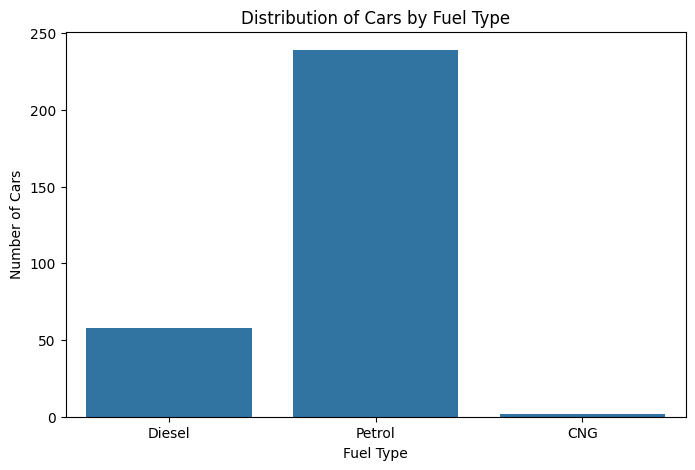

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Fuel_Type')
plt.title("Distribution of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.show()

In [54]:
# Again visually it verify that, the dataset is dominated by Petrol vehicles, followed by Diesel, while CNG vehicles are very limited.

Selling Price Distribution


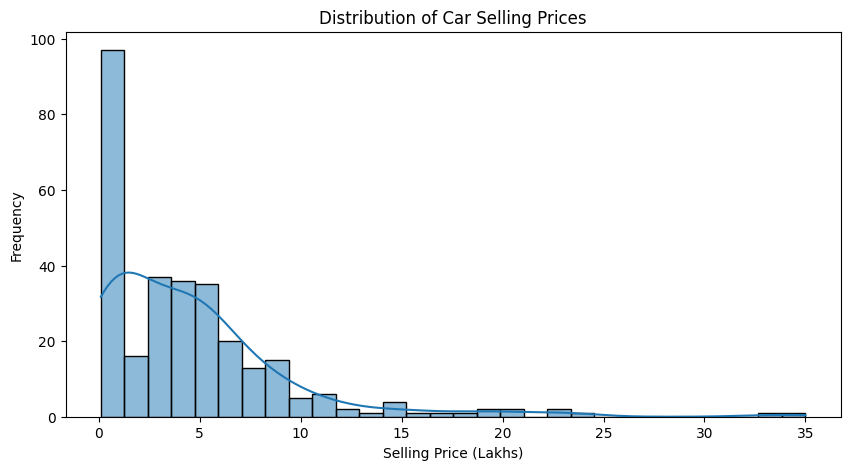

In [55]:
print('Selling Price Distribution')
plt.figure(figsize=(10,5))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

Insight to be noted is "Most cars in the dataset belong to the lower-to-mid price range, while a small number of expensive vehicles create a right-skewed distribution."

Avg SP By Fuel Type


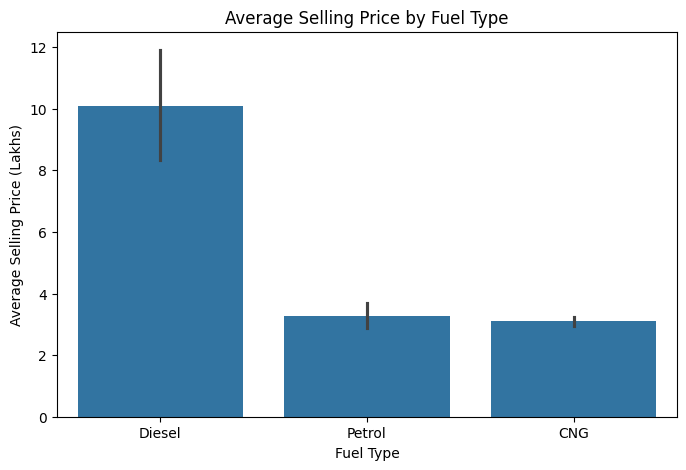

In [56]:
print("Avg SP By Fuel Type")
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Fuel_Type',
    y='Selling_Price')
plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price (Lakhs)") #asssumed data is in LAKH to be practical with numbers
plt.show()

In [57]:
print('Above Graph and his NUMBERS verifies each other')
avg_sp_by_fuel = df.groupby('Fuel_Type')['Selling_Price'].mean()
print("Average Selling Price by Fuel Type (Lakhs):")
print(avg_sp_by_fuel.round(2))


Above Graph and his NUMBERS verifies each other
Average Selling Price by Fuel Type (Lakhs):
Fuel_Type
CNG        3.10
Diesel    10.10
Petrol     3.26
Name: Selling_Price, dtype: float64


Insight: Diesel cars have the highest average selling price in this dataset.

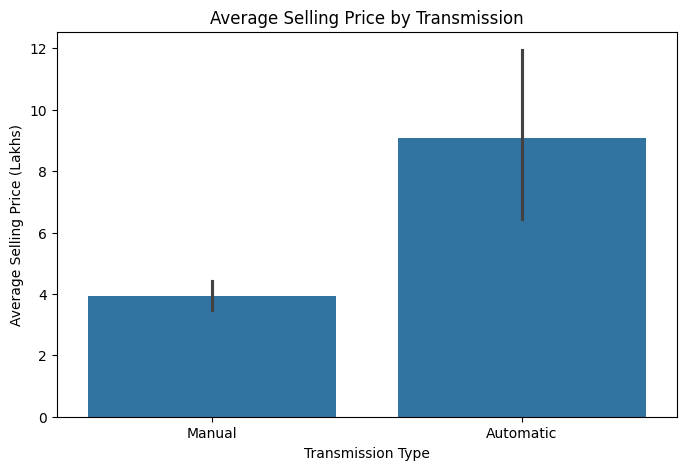

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Transmission',
    y='Selling_Price')
plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission Type")
plt.ylabel("Average Selling Price (Lakhs)")
plt.show()

In [59]:
avg_sp_by_transmission = df.groupby('Transmission')['Selling_Price'].mean()
print("Average Selling Price by Transmission (Lakhs):")
print(avg_sp_by_transmission.round(2))

Average Selling Price by Transmission (Lakhs):
Transmission
Automatic    9.07
Manual       3.92
Name: Selling_Price, dtype: float64



Insight

Automatic cars generally have a significantly higher selling price than manual cars in this dataset.

In [60]:
avg_pp_by_transmission = df.groupby('Transmission')['Present_Price'].mean()
print("Average Present Price by Transmission (Lakhs):")
print(avg_pp_by_transmission.round(2))

Average Present Price by Transmission (Lakhs):
Transmission
Automatic    14.92
Manual        6.43
Name: Present_Price, dtype: float64


Insight:

Notably, Automatic cars do also hava a significally higher Present Price than Manual Cars

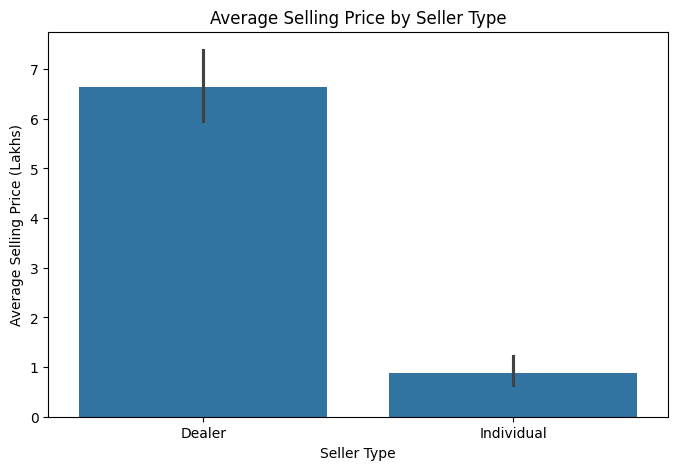

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Seller_Type',
    y='Selling_Price')
plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price (Lakhs)")
plt.show()

In [62]:
avg_sp_by_stype = df.groupby('Seller_Type')['Selling_Price'].mean()
print("Average Seller Price by Seller Type (Lakhs):")
print(avg_sp_by_stype.round(2))

Average Seller Price by Seller Type (Lakhs):
Seller_Type
Dealer        6.63
Individual    0.87
Name: Selling_Price, dtype: float64


In [63]:
#Cars sold by dealers tend to have substantially higher prices than cars sold by individuals.

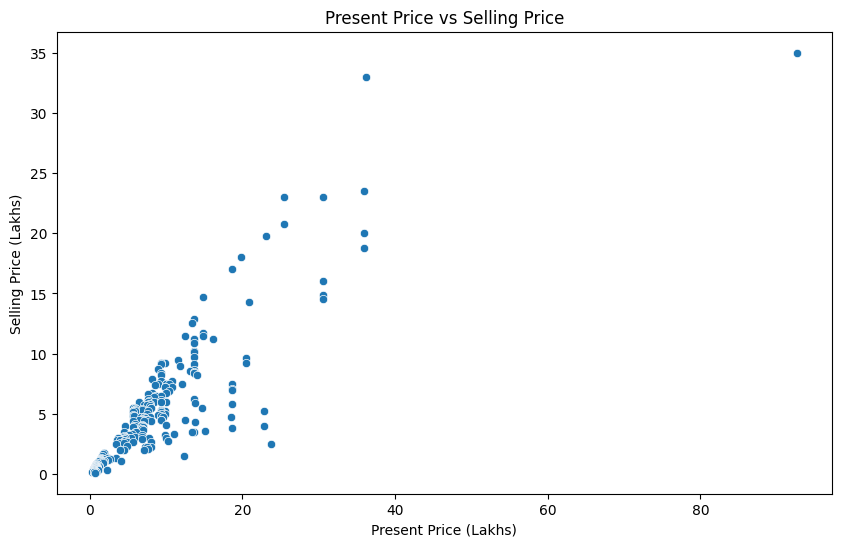

In [64]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Present_Price',
    y='Selling_Price')
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

In [65]:
corre = df['Present_Price'].corr(df['Selling_Price'])
print(f"The exact correlation between Present Price and Selling Price is: {corre:.3f}")

The exact correlation between Present Price and Selling Price is: 0.876


A correlation of 0.876 is very close to 1.0 (which would be a perfect 1:1 match). This means the Present Price is an incredibly reliable tool for predicting the Selling Price.

Year By SP


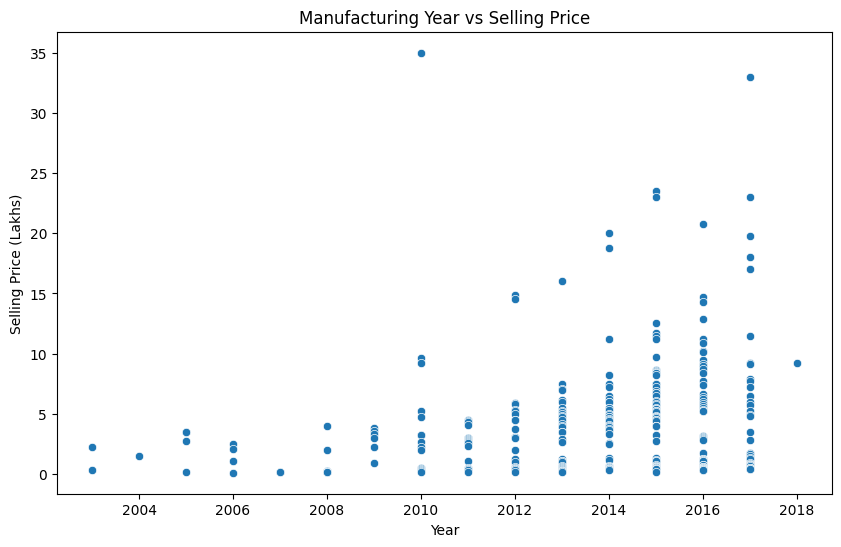

In [66]:
print('Year By SP')
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Year',
    y='Selling_Price')
plt.title("Manufacturing Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

In [67]:
#Generally, newer vehicles tend to have higher selling prices, although the relationship isn't perfectly linear because brand and original price also matter.

In [80]:
CURRENT_YEAR = 2026
df['Car_Age'] = CURRENT_YEAR - df['Year']
df[['Car_Name','Year','Car_Age']].head()

,Car_Name,Year,Car_Age
0,land cruiser,2010,16
1,fortuner,2017,9
2,fortuner,2015,11
3,fortuner,2015,11
4,innova,2017,9


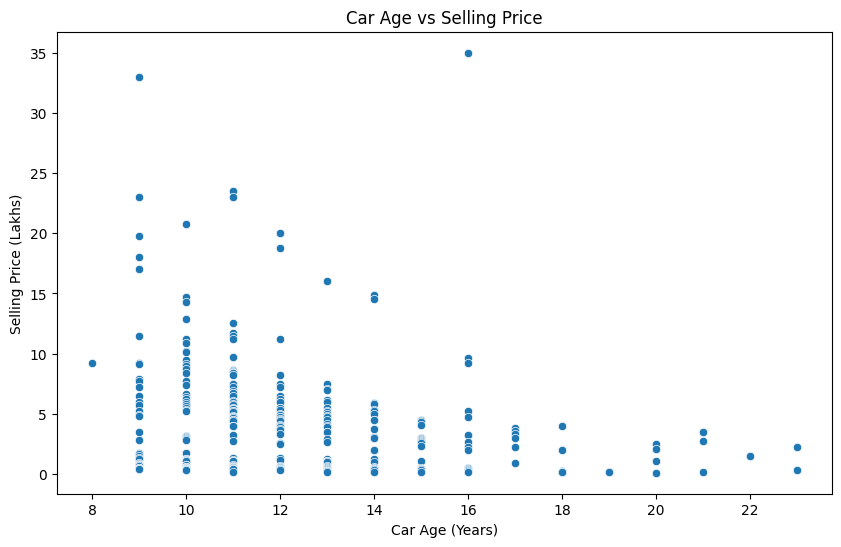

In [79]:
plt.figure(figsize=(10,6))
sns.scatterplot( data=df, x='Car_Age', y='Selling_Price')
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

Insight:

Older cars generally tend to have lower selling prices, demonstrating the impact of vehicle depreciation on resale value.

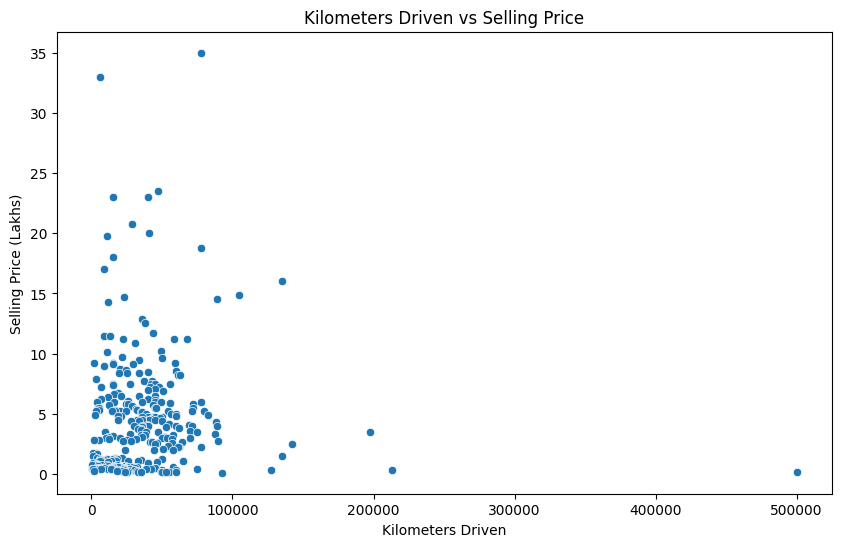

In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Kms_Driven',
    y='Selling_Price')
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

In [69]:
#Cars with high mileage generally tend to have lower resale value, although the dataset shows that mileage alone is not as strong a predictor as Present Price.

In [70]:
df['Car_Name'].str.upper()

,Car_Name
0,LAND CRUISER
1,FORTUNER
2,FORTUNER
3,FORTUNER
4,INNOVA
...,...
296,ACTIVA 3G
297,HONDA CB TWISTER
298,BAJAJ DISCOVER 125
299,HONDA CB SHINE


Top 10 Most Common Cars


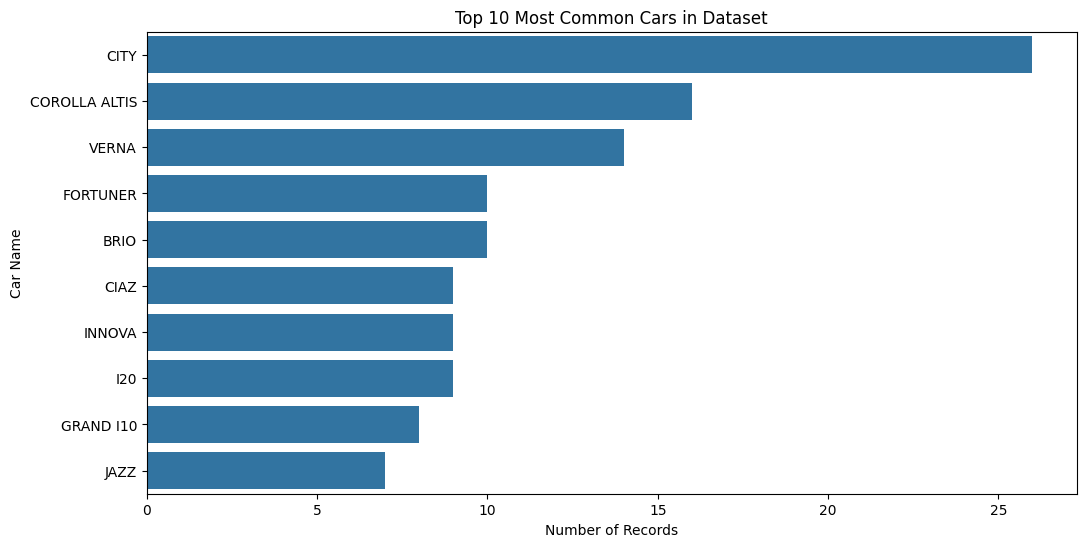

In [71]:
print('Top 10 Most Common Cars')
top_cars = df['Car_Name'].str.upper().value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_cars.values, y=top_cars.index)
plt.title("Top 10 Most Common Cars in Dataset")
plt.xlabel("Number of Records")
plt.ylabel("Car Name")
plt.show()

In [77]:
print('Insight:')
honda_ct = df[df['Car_Name'].str.contains('city', case=False)]['Car_Name'].count()
print(f"Most Popular Car is Honda City with: {honda_ct} records")


Insight:
Most Popular Car is Honda City with: 26 records


Correlational HeatMap


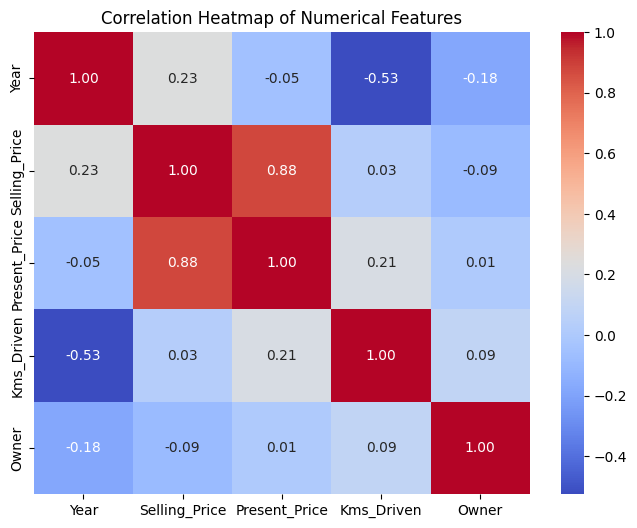

In [73]:
print('Correlational HeatMap')
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Insight:

Present Price has a strong positive correlation (0.876) with Selling Price, indicating that cars with higher present prices generally tend to have higher resale values.

**********************************************************************

Conclusion

This project analyzed used car market data from CarDekho to identify key trends influencing vehicle selling prices.

Key findings include:

Present Price has a strong positive relationship with Selling Price.

Diesel vehicles have higher average selling prices in the dataset.

Automatic cars generally have higher resale values than manual cars.

Dealer-listed cars have higher average selling prices compared to individual sellers.

Newer vehicles generally retain higher resale value.

Higher vehicle age and mileage can contribute to depreciation.

Petrol and Manual transmission vehicles dominate the dataset.



Overall, the analysis demonstrates that vehicle pricing depends on multiple factors, with Present Price, vehicle characteristics, and market category being important indicators of resale value.